<a href="https://colab.research.google.com/github/nuzularamadhani3-alt/AAEProject/blob/main/ab_ae_grid_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Persiapan Environtment

In [ ]:
#cell 1
!pip install pytorch-msssim

In [ ]:
#cell 2
import os
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
from pytorch_msssim import ssim
import glob
import torch.optim as optim
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve
import torch.nn.functional as F
import math
import cv2

In [ ]:
#cell 3
base_path = '/content/drive/MyDrive/ab_ae/data/mvtec/'

# Cek apakah path valid
if os.path.exists(base_path):
    print(f"✅ Path ditemukan: {base_path}")
    print("Isi folder:")
    # Menampilkan isi folder
    contents = os.listdir(base_path)
    print(contents)

    # Cek spesifik untuk 3 kategori Sabri
    targets = ['grid', 'screw', 'zipper']
    available = [t for t in targets if t in contents]
    print(f"\nKategori target yang ditemukan: {available}")
else:
    print(f"❌ Path TIDAK ditemukan: {base_path}")
    print("Pastikan Google Drive sudah ter-mount dengan benar di panel kiri.")

✅ Path ditemukan: /content/drive/MyDrive/ab_ae/data/mvtec/
Isi folder:
['screw', 'grid', 'zipper']

Kategori target yang ditemukan: ['grid', 'screw', 'zipper']


# Pra-Pemrosesan Data (Preprocessing Data)

In [ ]:
#Cell 4
# Konfigurasi Path
source_path = '/content/drive/MyDrive/ab_ae/data/mvtec/'
target_path = '/content/drive/MyDrive/ab_ae/data/mvtec_processed_v3/'
categories = ['grid', 'zipper']

def make_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

def process_and_crop(image_paths, dest_folder):
    """Fungsi pembantu untuk melakukan crop dan save berdasarkan list path gambar"""
    make_dir(dest_folder)
    patch_id_global = 0

    for img_path in image_paths:
        try:
            img = Image.open(img_path).convert('L')
        except:
            continue

        base_name = os.path.splitext(os.path.basename(img_path))[0]

        # Loop Y dan X (Sesuai parameter asli)
        for y in range(0, 1024, 256):
            for x in range(0, 1024, 256):
                box = (x, y, x + 256, y + 256)
                patch = img.crop(box).resize((128, 128))

                save_name = f"{base_name}_patch{patch_id_global}.png"
                save_path = os.path.join(dest_folder, save_name)
                patch.save(save_path)
                patch_id_global += 1

def prepare_leak_free_dataset(val_ratio=0.2):
    for category in categories:
        print(f"\n🚀 Memproses & Splitting kategori: {category}...")
        cat_path = os.path.join(source_path, category)
        if not os.path.exists(cat_path): continue

        # ==========================================
        # 1. HANDLING DATA TRAINING & VALIDASI
        # ==========================================
        train_good_dir = os.path.join(cat_path, 'train', 'good')
        all_good_imgs = glob.glob(os.path.join(train_good_dir, '*.png'))

        # SPLIT DI LEVEL GAMBAR UTUH SEBELUM DICROP (NO DATA LEAKAGE)
        train_imgs, val_imgs = train_test_split(all_good_imgs, test_size=val_ratio, random_state=42)

        print(f"   -> Split Gambar Asli: {len(train_imgs)} Train | {len(val_imgs)} Validasi")

        # Crop dan simpan ke folder yang benar-benar terpisah
        dest_train = os.path.join(target_path, category, 'train', 'good')
        dest_val = os.path.join(target_path, category, 'val', 'good') # Folder Val tersendiri

        process_and_crop(train_imgs, dest_train)
        process_and_crop(val_imgs, dest_val)

        # ==========================================
        # 2. HANDLING DATA TESTING (Tidak Perlu Split)
        # ==========================================
        test_dir = os.path.join(cat_path, 'test')
        for defect_folder in os.listdir(test_dir):
            defect_path = os.path.join(test_dir, defect_folder)
            if not os.path.isdir(defect_path): continue

            test_imgs = glob.glob(os.path.join(defect_path, '*.png'))
            dest_test = os.path.join(target_path, category, 'test', defect_folder)
            process_and_crop(test_imgs, dest_test)

        print(f"✅ Kategori {category} selesai tanpa kebocoran data!")

# Eksekusi
prepare_leak_free_dataset(val_ratio=0.2)


🚀 Memproses & Splitting kategori: grid...
   -> Split Gambar Asli: 211 Train | 53 Validasi
✅ Kategori grid selesai tanpa kebocoran data!

🚀 Memproses & Splitting kategori: zipper...
   -> Split Gambar Asli: 192 Train | 48 Validasi
✅ Kategori zipper selesai tanpa kebocoran data!


In [ ]:
#Cell 5
class MVTecDatasetV2(Dataset):
    def __init__(self, root_dir, category, mode='train', transform=None):
        self.transform = transform
        self.mode = mode
        self.image_paths = []

        # Mengambil data berdasarkan mode dari folder fisik yang sudah dipisah
        cat_path = os.path.join(root_dir, category)

        if mode == 'train':
            search_path = os.path.join(cat_path, 'train', 'good', '*.png')
        elif mode == 'val':
            search_path = os.path.join(cat_path, 'val', 'good', '*.png')
        elif mode == 'test':
            search_path = os.path.join(cat_path, 'test', '**', '*.png')

        self.image_paths.extend(glob.glob(search_path, recursive=True))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        return image, img_path

data_transforms = transforms.Compose([transforms.ToTensor()])

print("✅ Class MVTecDataset berhasil didefinisikan.")

✅ Class MVTecDataset berhasil didefinisikan.


In [ ]:
#Cell 6
BATCH_SIZE = 16
CATEGORY = 'grid'
ROOT_DIR_V2 = '/content/drive/MyDrive/ab_ae/data/mvtec_processed_v3/'

# Load langsung dari folder masing-masing
train_dataset = MVTecDatasetV2(root_dir=ROOT_DIR_V2, category=CATEGORY, mode='train', transform=data_transforms)
val_dataset = MVTecDatasetV2(root_dir=ROOT_DIR_V2, category=CATEGORY, mode='val', transform=data_transforms)
test_dataset = MVTecDatasetV2(root_dir=ROOT_DIR_V2, category=CATEGORY, mode='test', transform=data_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"📊 Dataset Bebas Kebocoran Siap!")
print(f"Data Training: {len(train_dataset)} patch")
print(f"Data Validasi: {len(val_dataset)} patch")
print(f"Data Testing: {len(test_dataset)} patch")

📊 Dataset Bebas Kebocoran Siap!
Data Training: 3376 patch
Data Validasi: 848 patch
Data Testing: 1248 patch


# DSSIM

In [ ]:
#Cell 7
class SSIMLoss(nn.Module):
    def __init__(self, window_size=11):
        """
        Args:
            window_size: Ukuran window (Sabri menggunakan 7, 11, atau 15).
                         Default di set 11 sesuai hasil terbaik Screw[cite: 16].
        """
        super(SSIMLoss, self).__init__()
        self.window_size = window_size

    def forward(self, img1, img2):
        # Hitung nilai SSIM (return range 0 s/d 1)
        # val_range=1.0 karena data kita sudah dinormalisasi ke 0-1
        ssim_val = ssim(img1, img2, data_range=1.0, size_average=True, win_size=self.window_size)

        # Hitung DSSIM (Distance) sesuai rumus Sabri
        # Loss = (1 - SSIM) / 2
        loss = (1 - ssim_val) / 2

        return loss

print("✅ Fungsi Loss DSSIM siap digunakan.")

✅ Fungsi Loss DSSIM siap digunakan.


# Perancangan Model

In [ ]:
#Cell 8
class AdaptiveAutoencoder(nn.Module):
    def __init__(self, latent_dim=500): # Kita set MAX (500) agar dia bisa adaptasi turun
        super(AdaptiveAutoencoder, self).__init__()

        # --- ENCODER (Sama seperti sebelumnya) ---
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
        )

        # --- BOTTLENECK (Raw Features) ---
        # Output Encoder adalah 32 channel x 8x8.
        # Kita ubah jadi vektor 500 (latent_dim)
        self.bottleneck_conv = nn.Conv2d(32, latent_dim, 8, 1, 0) # Output: 500x1x1

        # --- ADAPTIVE MODULE (NOVELTY) ---
        # Gating Network: Melihat fitur, lalu memutuskan mana yang disimpan (1) atau dibuang (0)
        self.gating = nn.Sequential(
            nn.Flatten(),
            nn.Linear(latent_dim, latent_dim),
            nn.Sigmoid() # Wajib Sigmoid agar output 0 s/d 1
        )

        # --- DECODER (Sama seperti sebelumnya) ---
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 32, 8, 1, 0), nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 1. Encode
        features = self.encoder(x)

        # 2. Raw Bottleneck (Z)
        z = self.bottleneck_conv(features) # Shape: [Batch, 500, 1, 1]

        # 3. Hitung Mask (0-1)
        mask = self.gating(z) # Shape: [Batch, 500]
        mask = mask.view(z.shape) # Reshape biar sama: [Batch, 500, 1, 1]

        # 4. Terapkan Mask (Perkalian)
        z_adaptive = z * mask

        # 5. Decode
        reconstruction = self.decoder(z_adaptive)

        # PENTING: Return juga 'mask' agar bisa didenda di loss function
        return reconstruction, mask

# Instansiasi Model Baru (Latent 500)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdaptiveAutoencoder(latent_dim=500).to(device)
print("✅ Adaptive Autoencoder siap!")

# Menghitung total parameter yang dilatih
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"📊 Total Parameter Model: {total_params:,}")

# Konversi perkiraan ke ukuran file (MB) dengan asumsi float32 (4 bytes)
size_mb = (total_params * 4) / (1024 ** 2)
print(f"💾 Perkiraan Ukuran Model: {size_mb:.2f} MB")

✅ Adaptive Autoencoder siap!
📊 Total Parameter Model: 2,939,641
💾 Perkiraan Ukuran Model: 11.21 MB


# Formulasi Fungsi Kerugian (Loss Function) & Konfigurasi Hiperparameter dan Optimasi

In [ ]:
#cell 9
# --- CELL 9: Training Loop dengan Validasi (Revisi) ---

def train_model_adaptive_with_val(model, train_loader, val_loader, epochs=100, lambda_val=0.001):
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

    # List untuk menyimpan riwayat loss (untuk plotting nanti)
    history = {'train': [], 'val': []}

    # Path penyimpanan
    last_ckpt_path = os.path.join('/content/drive/MyDrive/ab_ae/checkpointsgridfinal/', 'last_checkpoint_adaptive.pth')
    best_model_path = os.path.join('/content/drive/MyDrive/ab_ae/checkpointsgridfinal/', 'best_model_adaptive.pth')

    best_val_loss = float('inf')

    print(f"🚀 Mulai Training Adaptif (Lambda={lambda_val}) dengan Validasi...")
    start_time = time.time()

    for epoch in range(epochs):
        # ==========================
        # 1. FASE TRAINING
        # ==========================
        model.train() # Aktifkan mode training (BatchNorm/Dropout aktif)
        train_loss_total = 0.0

        for images, _ in train_loader:
            images = images.to(device)

            # Forward
            outputs, mask = model(images)

            # Hitung Loss
            l_recon = criterion(images, outputs)
            l_sparsity = torch.mean(mask)
            loss = l_recon + (lambda_val * l_sparsity)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_total += loss.item()

        # Rata-rata Training Loss
        avg_train_loss = train_loss_total / len(train_loader)

        # ==========================
        # 2. FASE VALIDASI
        # ==========================
        model.eval() # Aktifkan mode evaluasi (BatchNorm freeze)
        val_loss_total = 0.0

        with torch.no_grad(): # Matikan gradien agar hemat memori
            for images, _ in val_loader:
                images = images.to(device)

                # Forward
                outputs, mask = model(images)

                # Hitung Loss (Sama rumusnya dengan training)
                l_recon = criterion(images, outputs)
                l_sparsity = torch.mean(mask)
                loss = l_recon + (lambda_val * l_sparsity)

                val_loss_total += loss.item()

        # Rata-rata Validation Loss
        avg_val_loss = val_loss_total / len(val_loader)

        # Simpan History
        history['train'].append(avg_train_loss)
        history['val'].append(avg_val_loss)

        # ==========================
        # 3. LOGGING & SAVING
        # ==========================
        # Simpan checkpoint terakhir
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
            'best_val_loss': best_val_loss
        }, last_ckpt_path)

        # Simpan Model Terbaik berdasarkan VALIDATION LOSS (Bukan Training Loss)
        # Ini mencegah Overfitting (Saat Train turun terus, tapi Val mulai naik)
        save_msg = ""
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), best_model_path)
            save_msg = "💾 Best Val Saved!"

        # Print per epoch
        print(f"Ep [{epoch+1}/{epochs}] Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} {save_msg}")

    total_time = time.time() - start_time
    print(f"✅ Training Selesai dalam {total_time/60:.2f} menit!")

    return history

In [ ]:
#cell 10
# --- CELL 10: Eksekusi Training ---

# 1. Inisialisasi Loss Function
criterion = SSIMLoss(window_size=11).to(device)

# 2. Jalankan Training
# Pastikan val_loader sudah ada dari kode Split Data sebelumnya
history_adaptive = train_model_adaptive_with_val(
    model,
    train_loader,
    val_loader,  # Masukkan val_loader di sini
    epochs=100,
    lambda_val=0.001
)

🚀 Mulai Training Adaptif (Lambda=0.001) dengan Validasi...
Ep [1/100] Train: 0.3474 | Val: 0.3248 💾 Best Val Saved!
Ep [2/100] Train: 0.3280 | Val: 0.3241 💾 Best Val Saved!
Ep [3/100] Train: 0.3272 | Val: 0.3238 💾 Best Val Saved!
Ep [4/100] Train: 0.3269 | Val: 0.3236 💾 Best Val Saved!
Ep [5/100] Train: 0.3267 | Val: 0.3232 💾 Best Val Saved!
Ep [6/100] Train: 0.3265 | Val: 0.3230 💾 Best Val Saved!
Ep [7/100] Train: 0.3262 | Val: 0.3228 💾 Best Val Saved!
Ep [8/100] Train: 0.2661 | Val: 0.2231 💾 Best Val Saved!
Ep [9/100] Train: 0.1914 | Val: 0.1883 💾 Best Val Saved!
Ep [10/100] Train: 0.1615 | Val: 0.1598 💾 Best Val Saved!
Ep [11/100] Train: 0.1440 | Val: 0.1450 💾 Best Val Saved!
Ep [12/100] Train: 0.1289 | Val: 0.1311 💾 Best Val Saved!
Ep [13/100] Train: 0.1177 | Val: 0.1198 💾 Best Val Saved!
Ep [14/100] Train: 0.1075 | Val: 0.1090 💾 Best Val Saved!
Ep [15/100] Train: 0.0970 | Val: 0.1004 💾 Best Val Saved!
Ep [16/100] Train: 0.0920 | Val: 0.0945 💾 Best Val Saved!
Ep [17/100] Train: 0.0

# Visualisasi Kurva Loss Training vs Validation

💾 Memori sesi kosong. Memuat data history dari Checkpoint Google Drive...
✅ Grafik perbandingan tersimpan di: /content/drive/MyDrive/ab_ae/loss_curve_comparison_grid_final.png


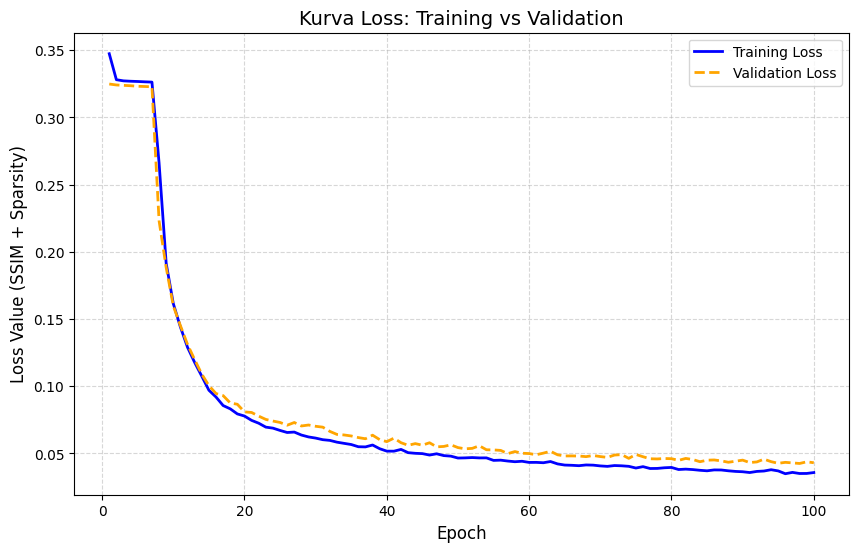

In [ ]:
#Cell 11
# --- CELL 11: Visualisasi Perbandingan Train vs Val (REVISI) ---
def plot_training_validation_loss(history):
    plt.figure(figsize=(10, 6))

    epochs_range = range(1, len(history['train']) + 1)

    # Plot Training Loss
    plt.plot(epochs_range, history['train'], label='Training Loss', color='blue', linewidth=2)

    # Plot Validation Loss
    plt.plot(epochs_range, history['val'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')

    plt.title('Kurva Loss: Training vs Validation', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss Value (SSIM + Sparsity)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    # Simpan gambar
    save_path = '/content/drive/MyDrive/ab_ae/loss_curve_comparison_grid_final.png'
    plt.savefig(save_path)
    print(f"✅ Grafik perbandingan tersimpan di: {save_path}")
    plt.show()

# --- LOGIKA CERDAS UNTUK MEMUAT HISTORY ---
checkpoint_path = '/content/drive/MyDrive/ab_ae/checkpointsgridfinal/last_checkpoint_adaptive.pth'

if 'history_adaptive' in locals() and len(history_adaptive['train']) > 0:
    # Skenario 1: Baru saja selesai training (Data ada di RAM)
    print("📊 Menggunakan data history dari memori sesi ini...")
    plot_training_validation_loss(history_adaptive)

elif os.path.exists(checkpoint_path):
    # Skenario 2: Restart Session (Data diambil dari Google Drive)
    print("💾 Memori sesi kosong. Memuat data history dari Checkpoint Google Drive...")

    # Load checkpoint (gunakan map_location='cpu' agar aman walau tidak pakai GPU)
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

    # Ekstrak dictionary history
    if 'history' in checkpoint:
        loaded_history = checkpoint['history']
        plot_training_validation_loss(loaded_history)
    else:
        print("⚠️ Checkpoint ditemukan, tapi tidak ada data 'history' di dalamnya.")
else:
    # Skenario 3: Belum pernah training sama sekali
    print("⚠️ Data history tidak ditemukan di memori maupun di Google Drive.")
    print("Anda harus menjalankan training (Cell 9 & 10) minimal satu kali.")

# Analisis & Visualisasi Distribusi Sparsitas Aktivasi Gate

✅ Model terlatih berhasil dimuat! Siap dianalisis.
📊 Rata-rata Aktivasi Gate untuk grid: 0.2303
✅ Grafik perbandingan tersimpan di: /content/drive/MyDrive/ab_ae/distribusi_aktivasi_gate_grid.png


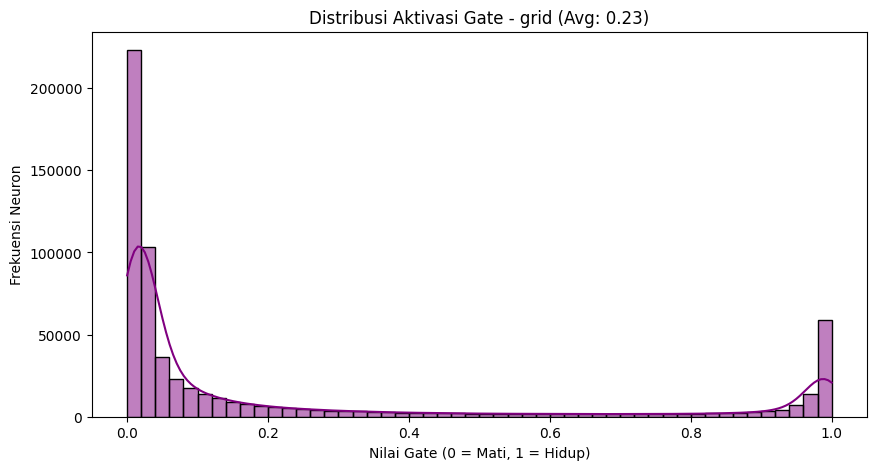

np.float32(0.23027377)

In [ ]:
#cell 12
def analyze_gate_activation(model, dataloader, category_name):
    model.eval()
    all_masks = []

    with torch.no_grad():
        for inputs, _ in dataloader:
            inputs = inputs.to(device)
            _, mask = model(inputs)
            # Ambil nilai mask (0 s/d 1) dan simpan
            all_masks.extend(mask.cpu().numpy().flatten())

    # Konversi ke numpy array
    all_masks = np.array(all_masks)
    avg_activation = np.mean(all_masks)

    print(f"📊 Rata-rata Aktivasi Gate untuk {category_name}: {avg_activation:.4f}")

    # Visualisasi Histogram Aktivasi
    plt.figure(figsize=(10, 5))
    sns.histplot(all_masks, bins=50, kde=True, color='purple')
    plt.title(f"Distribusi Aktivasi Gate - {category_name} (Avg: {avg_activation:.2f})")
    plt.xlabel("Nilai Gate (0 = Mati, 1 = Hidup)")
    plt.ylabel("Frekuensi Neuron")

    # Simpan gambar
    save_path = '/content/drive/MyDrive/ab_ae/distribusi_aktivasi_gate_grid.png'
    plt.savefig(save_path)
    print(f"✅ Grafik perbandingan tersimpan di: {save_path}")
    plt.show()

    return avg_activation

# 2. [PENTING] Load Bobot Terbaik Hasil Training
checkpoint_path = '/content/drive/MyDrive/ab_ae/checkpointsgridfinal/best_model_adaptive.pth'

if os.path.exists(checkpoint_path):
    # Load state dict
    model.load_state_dict(torch.load(checkpoint_path))
    print("✅ Model terlatih berhasil dimuat! Siap dianalisis.")
else:
    print("❌ File checkpoint tidak ditemukan. Pastikan path benar.")

# 3. Baru jalankan analisis
analyze_gate_activation(model, test_loader, 'grid')

# Segmentasi Anomali

In [ ]:
#cell 13
from sklearn.metrics import roc_auc_score

# Jalan tengah eksperimen stitching
# --- 1. SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. FUNGSI STITCHING FINAL (TIDAK BERUBAH) ---
def process_best_stitching(model, img_path, device, threshold, crop_size=256, model_input_size=128, stride=64):

    model.eval()
    try:
        img_pil = Image.open(img_path).convert('L')
    except:
        return None, None, None, None

    w_orig, h_orig = img_pil.size
    transform_to_tensor = transforms.ToTensor()
    pad = crop_size // 2
    img_tensor = transform_to_tensor(img_pil).to(device)
    img_padded = F.pad(img_tensor.unsqueeze(0), (pad, pad, pad, pad), mode='reflect').squeeze(0)
    h_pad, w_pad = img_padded.shape[1], img_padded.shape[2]

    full_error_map = torch.full((1, h_pad, w_pad), 10.0, device='cpu')
    full_recon_vis = torch.zeros((1, h_pad, w_pad), device='cpu')
    full_weight_vis = torch.zeros((1, h_pad, w_pad), device='cpu')

    hann = torch.hann_window(crop_size, periodic=False).to(device)
    vis_weight_mask = (hann.unsqueeze(1) * hann.unsqueeze(0)).view(1, crop_size, crop_size).cpu()

    patches_batch = []
    coords_batch = []

    for y in range(0, h_pad - crop_size + 1, stride):
        for x in range(0, w_pad - crop_size + 1, stride):
            patch = img_padded[:, y:y+crop_size, x:x+crop_size]
            patch_small = F.interpolate(patch.unsqueeze(0), size=(model_input_size, model_input_size), mode='bilinear', align_corners=False).squeeze(0)
            patches_batch.append(patch_small)
            coords_batch.append((x, y))

    if not patches_batch: return None, None, None, None

    batch_size = 32
    input_stack = torch.stack(patches_batch)

    with torch.no_grad():
        for i in range(0, len(input_stack), batch_size):
            inputs = input_stack[i:i+batch_size]
            recons = model(inputs)[0]
            errors = torch.abs(inputs - recons)
            errors_up = F.interpolate(errors, size=(crop_size, crop_size), mode='bilinear', align_corners=False).cpu()
            recons_up = F.interpolate(recons, size=(crop_size, crop_size), mode='bilinear', align_corners=False).cpu()

            base_idx = i
            for j in range(len(inputs)):
                idx = base_idx + j
                x, y = coords_batch[idx]
                current_min = full_error_map[:, y:y+crop_size, x:x+crop_size]
                full_error_map[:, y:y+crop_size, x:x+crop_size] = torch.min(current_min, errors_up[j])
                full_recon_vis[:, y:y+crop_size, x:x+crop_size] += recons_up[j] * vis_weight_mask
                full_weight_vis[:, y:y+crop_size, x:x+crop_size] += vis_weight_mask

    final_error = full_error_map[:, pad:pad+h_orig, pad:pad+w_orig]
    full_weight_vis[full_weight_vis == 0] = 1.0
    final_recon = (full_recon_vis / full_weight_vis)[:, pad:pad+h_orig, pad:pad+w_orig]
    final_pred = (final_error > threshold).float()

    return (
        img_tensor.squeeze().cpu().numpy(),
        final_recon.squeeze().numpy(),
        final_error.squeeze().numpy(),
        final_pred.squeeze().numpy()
    )

In [ ]:
#cell 14
import numpy as np
import torch

def find_threshold_from_validation_mae(
    model,
    val_loader,
    device,
    percentile=90.0,
    use_pixel_errors=True
):
    """
    Menghitung threshold anomali dari validation set normal-only menggunakan MAE/L1.

    Args:
        model: model autoencoder terlatih
        val_loader: DataLoader validation (hanya gambar normal/good)
        device: cuda/cpu
        percentile: persentil threshold, misalnya 95, 97.5, 99
        use_pixel_errors:
            True  -> threshold dari distribusi error pixel-level
            False -> threshold dari rata-rata error per image

    Returns:
        threshold (float)
    """
    print("🧪 Calibrating threshold from validation normal-only...")
    print(f"   Method      : {'Pixel-level MAE error' if use_pixel_errors else 'Image-level mean MAE error'}")
    print(f"   Percentile  : {percentile}%")
    model.eval()

    collected_scores = []

    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device)

            outputs, _ = model(images)

            # MAE/L1 error map per pixel
            error_map = torch.abs(images - outputs)

            if use_pixel_errors:
                # Ambil semua nilai pixel error dari batch
                collected_scores.append(error_map.detach().cpu().flatten().numpy())
            else:
                # Ambil satu skor per image (rata-rata error)
                mean_error = torch.mean(error_map, dim=[1, 2, 3])
                collected_scores.append(mean_error.detach().cpu().numpy())

    collected_scores = np.concatenate(collected_scores, axis=0)

    threshold = np.percentile(collected_scores, percentile)

    print("✅ Threshold calibration selesai!")
    print(f"   Jumlah skor yang dipakai : {len(collected_scores)}")
    print(f"   Min error                : {collected_scores.min():.6f}")
    print(f"   Mean error               : {collected_scores.mean():.6f}")
    print(f"   Max error                : {collected_scores.max():.6f}")
    print(f"   Best Threshold           : {threshold:.6f}")

    return float(threshold)


# Jalankan kalibrasi threshold dari validation normal-only
best_threshold = find_threshold_from_validation_mae(
    model,
    val_loader,
    device,
    percentile=90.0,       # bisa dicoba 95, 97.5, 99
    use_pixel_errors=True   # cocok untuk segmentasi anomali pixel-level
)

🧪 Calibrating threshold from validation normal-only...
   Method      : Pixel-level MAE error
   Percentile  : 90.0%
✅ Threshold calibration selesai!
   Jumlah skor yang dipakai : 13893632
   Min error                : 0.000000
   Mean error               : 0.029872
   Max error                : 0.497395
   Best Threshold           : 0.062131


# Evaluasi Model

In [ ]:
#cell 15
def evaluate_dataset_auc(model, category, root_dir, device, threshold=0.04):
    print(f"🚀 Memulai Evaluasi AUC Menyeluruh untuk: {category}...")
    model.eval()

    # List semua folder defect types (termasuk 'good' jika ada di test)
    test_dir = os.path.join(root_dir, category, 'test')
    defect_types = os.listdir(test_dir)

    all_aucs = []

    for defect_type in defect_types:
        defect_path = os.path.join(test_dir, defect_type)
        if not os.path.isdir(defect_path): continue

        image_files = os.listdir(defect_path)

        for img_name in tqdm(image_files, desc=f"Evaluating {defect_type}"):
            if not img_name.endswith('.png'): continue

            img_id = img_name.split('.')[0] # Ambil ID gambar

            # Jalankan Stitching (Gunakan fungsi process_best_stitching yang sudah ada)
            img_path = os.path.join(defect_path, img_name)

            # Note: Pastikan process_best_stitching mengembalikan error map yang utuh
            # Kita set threshold sembarang karena AUC tidak butuh threshold, tapi fungsi butuh input
            _, _, error_map, _ = process_best_stitching(
                model, img_path, device, threshold=threshold,
                crop_size=256, model_input_size=128, stride=64
            )

            if error_map is None: continue

            # Load Ground Truth
            gt_folder = os.path.join(root_dir, category, 'ground_truth', defect_type)
            gt_name = f"{img_id}_mask.png"
            gt_path = os.path.join(gt_folder, gt_name)

            # Jika file GT ada (berarti ini gambar cacat)
            if os.path.exists(gt_path):
                g = Image.open(gt_path).convert('L').resize((error_map.shape[1], error_map.shape[0]))
                gt_mask = (np.array(g).astype(np.float32) / 255.0 > 0.5).astype(np.float32)

                # Hitung AUC per gambar
                if np.max(gt_mask) > 0: # Hanya hitung jika ada cacat
                    score = roc_auc_score(gt_mask.flatten(), error_map.flatten())
                    all_aucs.append(score)

            # Jika tidak ada GT (Good image), biasanya di skip untuk segmentasi AUC pixel-level
            # atau dianggap full hitam (tapi ROC score butuh setidaknya 1 kelas positif)
            # Standar MVTec biasanya menghitung rata-rata AUC dari gambar defect saja untuk lokalisasi.

    if len(all_aucs) > 0:
        mean_auc = np.mean(all_aucs)
        print(f"\n✅ Rata-rata Pixel-Level AUC ({category}): {mean_auc:.4f}")
        return mean_auc
    else:
        print("\n⚠️ Tidak ada data valid untuk hitung AUC (Cek path Ground Truth)")
        return 0.0

# PENGGUNAAN:
# evaluate_dataset_auc(model_adaptive, 'zipper', '/content/drive/MyDrive/ab_ae/data/mvtec/', device)

# 3. Hitung Rata-rata AUC (Sub-bab 4.4) -> INI YANG BARU
# Hasil ini yang nanti kamu masukkan ke Tabel Perbandingan dengan Sabri
avg_auc = evaluate_dataset_auc(
    model,
    category='grid',
    root_dir='/content/drive/MyDrive/ab_ae/data/mvtec/', # Pastikan path sesuai dataset kamu
    device=device
)

🚀 Memulai Evaluasi AUC Menyeluruh untuk: grid...


Evaluating metal_contamination: 100%|██████████| 11/11 [00:15<00:00,  1.38s/it]


✅ Rata-rata Pixel-Level AUC (grid): 0.8632


🔄 Menghitung Macro-Average ROC (Rata-rata Kurva per Gambar) untuk: grid...


Processing Images: 100%|██████████| 78/78 [00:31<00:00,  2.48it/s]


📊 Rata-rata AUC Manual (sebagai cek): 0.8632
✅ Grafik Macro-ROC tersimpan di: /content/drive/MyDrive/ab_ae/macro_roc_grid.png
🌟 Nilai Macro-Average AUC Akhir: 0.8621


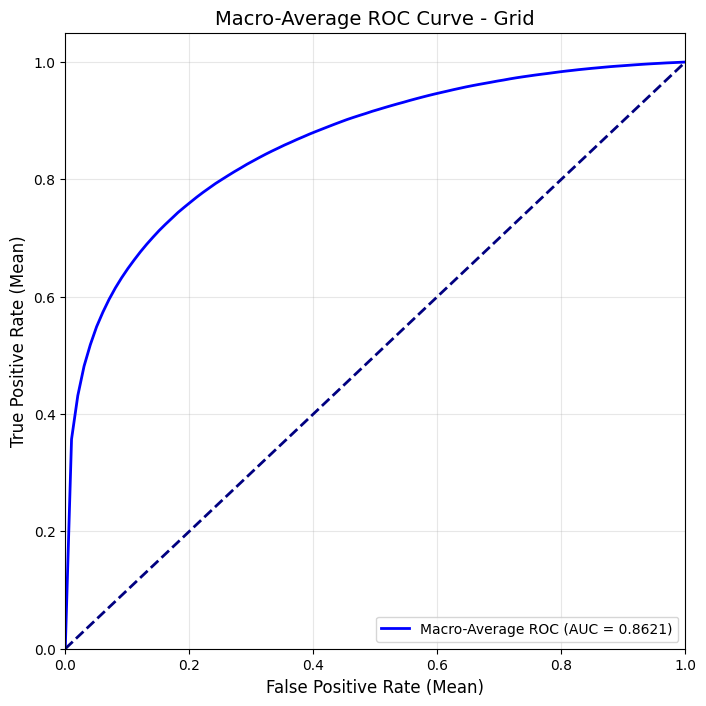

In [ ]:
#cell 16
# --- CELL 13c (MACRO-AVERAGE): Visualisasi ROC Curve Rata-rata per Gambar ---
from sklearn.metrics import roc_curve, auc
import numpy as np # numpy is already imported, so interp is available as np.interp
import matplotlib.pyplot as plt
import os
from PIL import Image
from tqdm import tqdm

def plot_macro_average_roc(model, root_dir_original, category, device):
    print(f"🔄 Menghitung Macro-Average ROC (Rata-rata Kurva per Gambar) untuk: {category}...")

    # Kumpulkan path gambar
    original_test_path = os.path.join(root_dir_original, category, 'test')
    all_image_paths = []
    for root, _, files in os.walk(original_test_path):
        for file in files:
            if file.endswith(('.png', '.jpg', '.jpeg')):
                all_image_paths.append(os.path.join(root, file))

    # Kita tentukan sumbu X (FPR) standar dari 0 sampai 1 (100 titik)
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    valid_aucs = []

    for img_path in tqdm(all_image_paths, desc="Processing Images"):

        # 1. Stitching
        _, _, error_map, _ = process_best_stitching(
            model, img_path, device, threshold=0.1,
            crop_size=256, model_input_size=128, stride=64
        )
        if error_map is None: continue

        # 2. Load Ground Truth
        parts = img_path.split(os.sep)
        img_id = os.path.splitext(parts[-1])[0]
        defect_type = parts[-2]

        gt_path = os.path.join(root_dir_original, category, 'ground_truth', defect_type, f"{img_id}_mask.png")

        gt_mask = np.zeros_like(error_map)
        if os.path.exists(gt_path):
            try:
                g = Image.open(gt_path).convert('L').resize((error_map.shape[1], error_map.shape[0]))
                gt_mask = (np.array(g).astype(np.float32) / 255.0 > 0.5).astype(np.float32)
            except:
                pass

        # 3. Hitung ROC Individu HANYA jika gambar memiliki cacat (GT > 0)
        # Jika gambar normal (Good), AUC tidak terdefinisi secara pixel-level lokal
        if np.max(gt_mask) > 0:
            fpr, tpr, _ = roc_curve(gt_mask.flatten(), error_map.flatten())

            # Interpolasi TPR agar cocok dengan mean_fpr
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0 # Pastikan mulai dari 0
            tprs.append(interp_tpr)

            # Hitung AUC individu untuk validasi
            valid_aucs.append(auc(fpr, tpr))

    # 4. Hitung Rata-rata Kurva
    if len(tprs) == 0:
        print("⚠️ Tidak ada gambar cacat yang valid untuk dihitung kurvanya.")
        return

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0 # Pastikan berakhir di 1
    mean_auc = auc(mean_fpr, mean_tpr)

    # Opsional: Cek rata-rata manual
    print(f"📊 Rata-rata AUC Manual (sebagai cek): {np.mean(valid_aucs):.4f}")

    # 5. Plotting
    plt.figure(figsize=(8, 8))
    plt.plot(mean_fpr, mean_tpr, color='blue', lw=2, label=f'Macro-Average ROC (AUC = {mean_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Mean)', fontsize=12)
    plt.ylabel('True Positive Rate (Mean)', fontsize=12)
    plt.title(f'Macro-Average ROC Curve - {category.capitalize()}', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    save_path = f'/content/drive/MyDrive/ab_ae/macro_roc_{category}.png'
    plt.savefig(save_path)
    print(f"✅ Grafik Macro-ROC tersimpan di: {save_path}")
    print(f"🌟 Nilai Macro-Average AUC Akhir: {mean_auc:.4f}")
    plt.show()

# Jalankan Fungsi
plot_macro_average_roc(model, '/content/drive/MyDrive/ab_ae/data/mvtec/', 'grid', device)

# Visualisasi Hasil Dataset

Running Scale-Corrected Min-Error Stitching for 010...
⚡ Waktu Inferensi 1 Gambar (Stitching): 246.42 ms
🎯 Pixel-Level AUC Score: 0.9420
✅ Hasil visualisasi tersimpan di: /content/drive/MyDrive/ab_ae/hasil_visualisasi/grid_thread_010.png


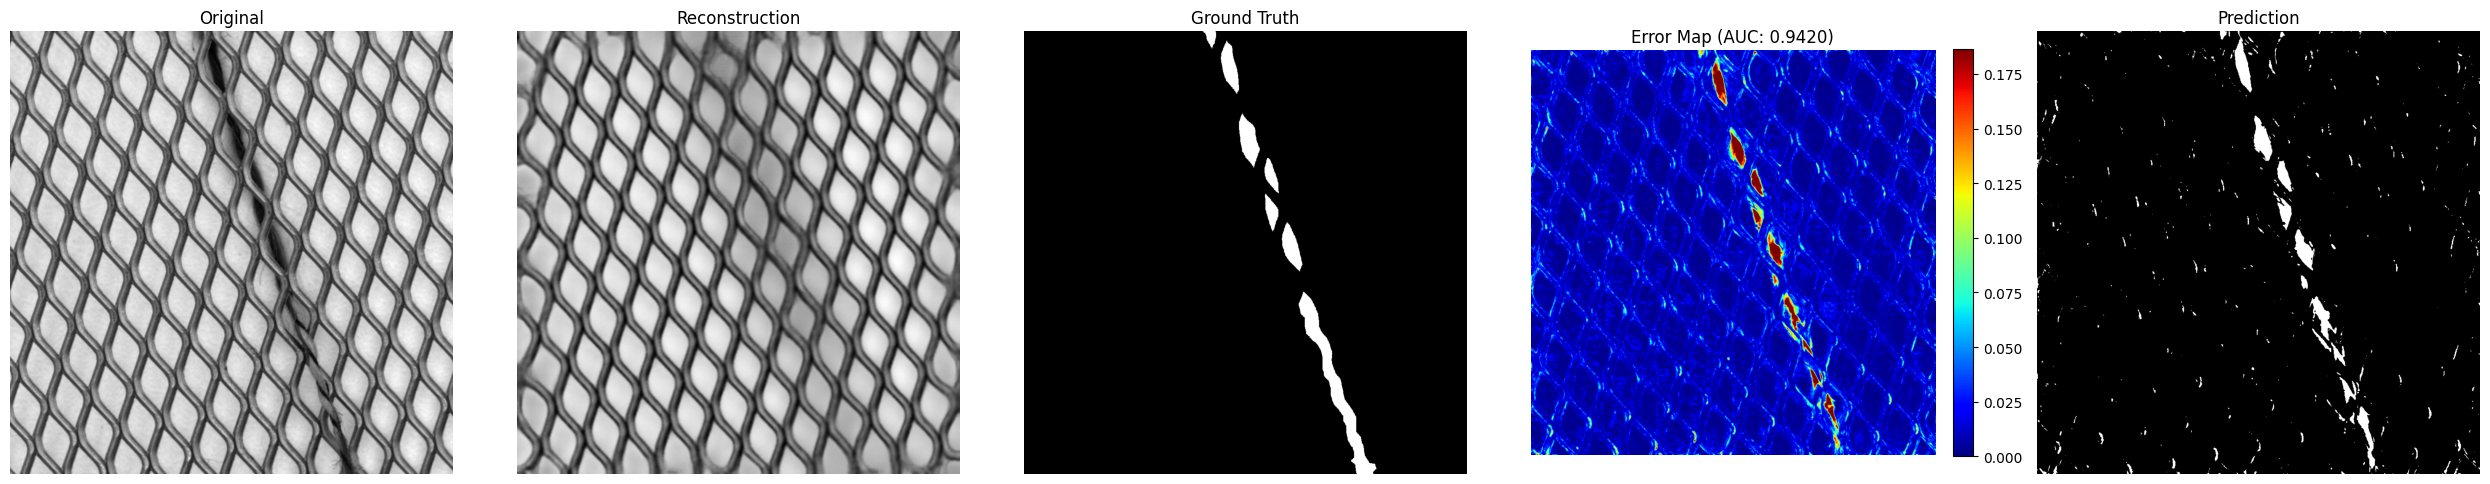

In [ ]:
#cell 17
import time
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score

# --- 3. VISUALISASI (DIMODIFIKASI UNTUK AUC & INFERENCE TIME) ---
def visualize_final_check(model, category, defect_type, img_id, root_dir, device, threshold):
    # Cari file
    target_path = os.path.join(root_dir, category, 'test', defect_type, f"{img_id}.png")
    if not os.path.exists(target_path):
        target_path = os.path.join(root_dir, category, 'test', defect_type, f"{int(img_id):03d}.png")
        if not os.path.exists(target_path):
            print(f"❌ File tidak ditemukan: {target_path}")
            return

    print(f"Running Scale-Corrected Min-Error Stitching for {img_id}...")

    # --- [BAGIAN BARU] HITUNG WAKTU INFERENSI ---
    # 1. Pemanasan GPU (Sangat disarankan agar waktu stabil)
    _ = process_best_stitching(
        model, target_path, device, threshold,
        crop_size=256, model_input_size=128, stride=64
    )

    # 2. Mulai hitung waktu
    start_time = time.perf_counter()

    # 3. Jalankan Inferensi Utama
    orig, recon, error, pred = process_best_stitching(
        model, target_path, device, threshold,
        crop_size=256,
        model_input_size=128,
        stride=64
    )

    # 4. Akhiri hitung waktu
    end_time = time.perf_counter()
    inference_time = (end_time - start_time) * 1000 # Konversi ke milidetik (ms)

    if orig is None: return

    print(f"⚡ Waktu Inferensi 1 Gambar (Stitching): {inference_time:.2f} ms")
    # --------------------------------------------

    # Load GT
    gt_mask = np.zeros_like(orig)
    gt_folder = os.path.join(root_dir, category, 'ground_truth', defect_type)
    gt_name = f"{int(img_id):03d}_mask.png"
    gt_path = os.path.join(gt_folder, gt_name)

    # Flag untuk mengecek apakah GT tersedia dan valid (ada defectnya)
    has_gt = False

    if os.path.exists(gt_path):
        g = Image.open(gt_path).convert('L').resize((orig.shape[1], orig.shape[0]))
        gt_mask = (np.array(g).astype(np.float32) / 255.0 > 0.5).astype(np.float32)
        has_gt = True

    # --- HITUNG PIXEL-LEVEL AUC ---
    auc_score = 0.0
    auc_text = "N/A" # Default jika tidak ada GT atau gambar Good (tanpa defect)

    # Hanya bisa hitung AUC jika ada GT mask dan mask tersebut memiliki setidaknya satu pixel defect (kelas positif)
    # Jika gambar "Good", GT semua 0, AUC tidak terdefinisi (akan error di sklearn)
    if has_gt and np.max(gt_mask) > 0:
        # Flatten array menjadi 1D
        gt_flat = gt_mask.flatten()
        error_flat = error.flatten()

        # Hitung AUC
        auc_score = roc_auc_score(gt_flat, error_flat)
        auc_text = f"{auc_score:.4f}"
        print(f"🎯 Pixel-Level AUC Score: {auc_text}")
    elif np.max(gt_mask) == 0:
        print("🎯 Pixel-Level AUC: N/A (No defect pixels in Ground Truth)")
    # --------------------------------------------

    # Plot
    fig, ax = plt.subplots(1, 5, figsize=(25, 6))

    # Update judul plot Error Map dengan nilai AUC
    titles = ["Original", "Reconstruction", "Ground Truth", f"Error Map (AUC: {auc_text})", "Prediction"]
    images = [orig, recon, gt_mask, error, pred]

    for i, (a, img, title) in enumerate(zip(ax, images, titles)):
        if "Error" in title:
            im = a.imshow(img, cmap='jet', vmin=0, vmax=threshold*3)
            plt.colorbar(im, ax=a, fraction=0.046, pad=0.04)
        else:
            a.imshow(img, cmap='gray')
        a.set_title(title)
        a.axis('off')

    plt.tight_layout()

    # --- [BAGIAN BARU] SIMPAN GAMBAR DINAMIS ---
    # Menggunakan f-string untuk memasukkan variabel ke dalam nama file
    save_path = f'/content/drive/MyDrive/ab_ae/hasil_visualisasi/{category}_{defect_type}_{img_id}.png'
    plt.savefig(save_path, bbox_inches='tight') # bbox_inches='tight' agar gambar tidak terpotong
    print(f"✅ Hasil visualisasi tersimpan di: {save_path}")
    # -------------------------------------------

    plt.show()

# --- EKSEKUSI ---
if 'best_threshold' not in locals(): best_threshold = 0.04

visualize_final_check(
    model,
    category='grid',
    defect_type='thread',
    img_id='010',
    root_dir='/content/drive/MyDrive/ab_ae/data/mvtec/',
    device=device,
    threshold=best_threshold
)